<a href="https://colab.research.google.com/github/Poonam-1-3-7-9/New-Adventure-in-Bungee/blob/main/NLP_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing the libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading the CSV file into the environment
df = pd.read_csv('spam .csv')

In [3]:
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
# Printing the total number of rows and columns (dimensions)
print(df.shape)

(5572, 2)


In [5]:
# Checking the count of 'ham' vs 'spam' records
print(df["Category"].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


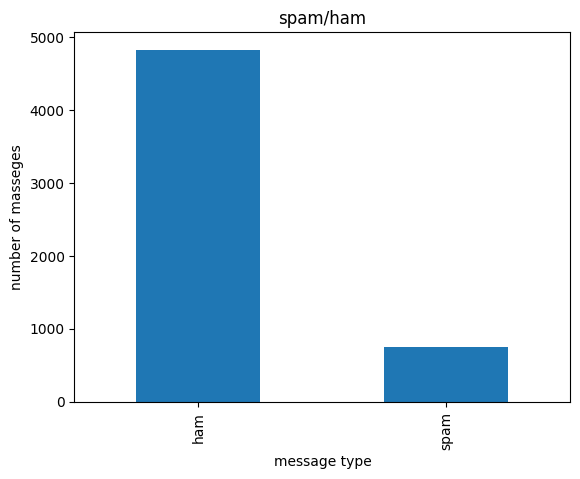

In [6]:
# Code to plot the bar chart (the instructor instructs to set labels and a title)
# After setting up the bar chart elements, the final line to display the visual:
counts=df["Category"].value_counts()
counts.plot(kind="bar")
plt.title('spam/ham')
plt.xlabel('message type')
plt.ylabel('number of masseges')
plt.show()

In [7]:
#Prepare the Data
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

In [8]:
#input and output
x=df["Message"]
y=df["Category"]

In [9]:
#split the data set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
#text to numbers
# Importing the CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [11]:
#text to numbers
# Importing the CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [14]:
# Initializing the CountVectorizer
vectorizer = CountVectorizer()
# Transforming training text data into numerical features
x_train_vector = vectorizer.fit_transform(x_train)
# Transforming test text data into numerical features (without fitting)
X_test_vector = vectorizer.transform(x_test)

In [15]:
#train model using logestic regression
# Importing the classification model
from sklearn.linear_model import LogisticRegression
# Initializing and training the model
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vector, y_train)

LogisticRegression(max_iter=1000)

In [16]:
# Making predictions on the test vector set
predictions = model.predict(X_test_vector)

In [17]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9856502242152466


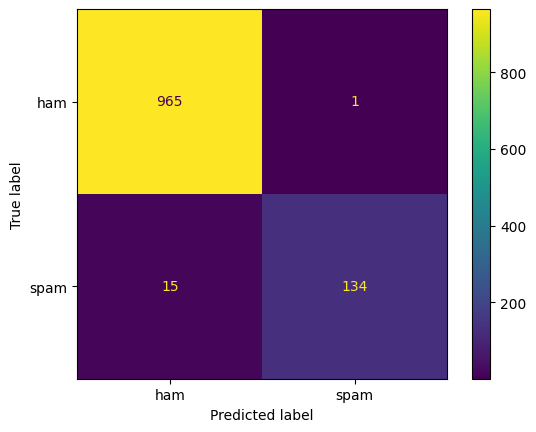

Confussion Matrix:
 [[965   1]
 [ 15 134]]


In [18]:
# Importing evaluation utilities
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

# Generating the raw confusion matrix values
confusion = confusion_matrix(y_test, predictions)

# Setting up and plotting the confusion matrix display
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['ham', 'spam'])
display.plot()
plt.show()
print("Confussion Matrix:\n",confusion)

In [19]:
message=input("Enter a message ")
message_vector=vectorizer.transform([message])
prediction=model.predict(message_vector)
if prediction[0]==1:
    print("Spam")
else:
    print("Ham")

Enter a message hello Poonam , here is your internship certificate 
Ham


In [20]:
message=input("Enter a message ")
message_vector=vectorizer.transform([message])
prediction=model.predict(message_vector)
if prediction[0]==1:
    print("Spam")
else:
    print("Ham")

Enter a message  You won $1000000. Click now on link to claim prize
Spam
